# Airbnb Data Analysis and Visualization

## Project Overview
This notebook provides an end-to-end exploratory analysis of the supplied Airbnb listings dataset: loading, cleaning, descriptive statistics, visualization, comparison, and business insights.

**Price note:** the dataset has no currency column, so `price` is treated as **dataset price units** and is not assumed to be USD.

## Objectives
- Understand dataset structure and quality.
- Clean inconsistent and missing values.
- Analyze price, ratings, reviews, capacity, and property characteristics.
- Compare listing volume and median prices across countries.
- Produce practical insights for hosts, guests, and analysts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 6)
df = pd.read_csv("airbnb.csv")
print("Shape:", df.shape)
display(df.head())


Shape: (12805, 23)


,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


## 1. Data Understanding

In [2]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Columns:
['Unnamed: 0', 'id', 'name', 'rating', 'reviews', 'host_name', 'host_id', 'address', 'features', 'amenities', 'safety_rules', 'hourse_rules', 'img_links', 'price', 'country', 'bathrooms', 'beds', 'guests', 'toiles', 'bedrooms', 'studios', 'checkin', 'checkout']

Data types:


,dtype
Unnamed: 0,int64
id,int64
name,object
rating,object
reviews,object
host_name,object
host_id,float64
address,object
features,object
amenities,object



Missing values:


,missing
checkout,2450
checkin,800
host_name,8
name,0
rating,0
id,0
Unnamed: 0,0
host_id,0
reviews,0
address,0


## 2. Data Cleaning

In [3]:
data = df.drop(columns=["Unnamed: 0"], errors="ignore").copy()
data["rating_numeric"] = pd.to_numeric(data["rating"], errors="coerce")
data["reviews_numeric"] = pd.to_numeric(data["reviews"], errors="coerce").fillna(0)
for col in ["price","bathrooms","beds","guests","toiles","bedrooms","studios"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data["country"] = data["country"].astype(str).str.strip()
data["host_name"] = data["host_name"].fillna("Unknown")
data["rating_status"] = np.where(data["rating_numeric"].isna(), "New", "Rated")
print("Cleaned shape:", data.shape)
display(data.head())


Cleaned shape: (12805, 25)


,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout,rating_numeric,reviews_numeric,rating_status
0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm,4.71,64.0,Rated
1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am,NaN,0.0,New
2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm,4.85,68.0,Rated
3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm,5.00,13.0,Rated
4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm,NaN,0.0,New


## 3. Descriptive Statistics

In [4]:
numeric_cols = ["price","rating_numeric","reviews_numeric","bathrooms","beds","guests","toiles","bedrooms","studios"]
display(data[numeric_cols].describe().T)
print("Unique countries:", data["country"].nunique())
print("Rated listings:", data["rating_numeric"].notna().sum())
print("New/unrated listings:", data["rating_numeric"].isna().sum())


,count,mean,std,min,25%,50%,75%,max
price,12805.0,17697.800312,45693.643225,393.0,3994.00,8175.00,16062.00,1907963.0
rating_numeric,8567.0,4.857475,0.140803,3.0,4.77,4.89,4.98,5.0
reviews_numeric,12805.0,36.061695,65.523759,0.0,1.00,10.00,42.00,943.0
bathrooms,12805.0,1.874424,2.091399,0.0,1.00,1.00,2.00,50.0
beds,12805.0,3.316751,4.037791,0.0,1.00,2.00,4.00,98.0
guests,12805.0,5.213745,3.808830,1.0,2.00,4.00,6.00,16.0
toiles,12805.0,0.019211,0.137272,0.0,0.00,0.00,0.00,1.0
bedrooms,12805.0,2.136041,2.359005,0.0,1.00,1.00,3.00,50.0
studios,12805.0,0.023585,0.151757,0.0,0.00,0.00,0.00,1.0


Unique countries: 119
Rated listings: 8567
New/unrated listings: 4238


## 4. Listings by Country

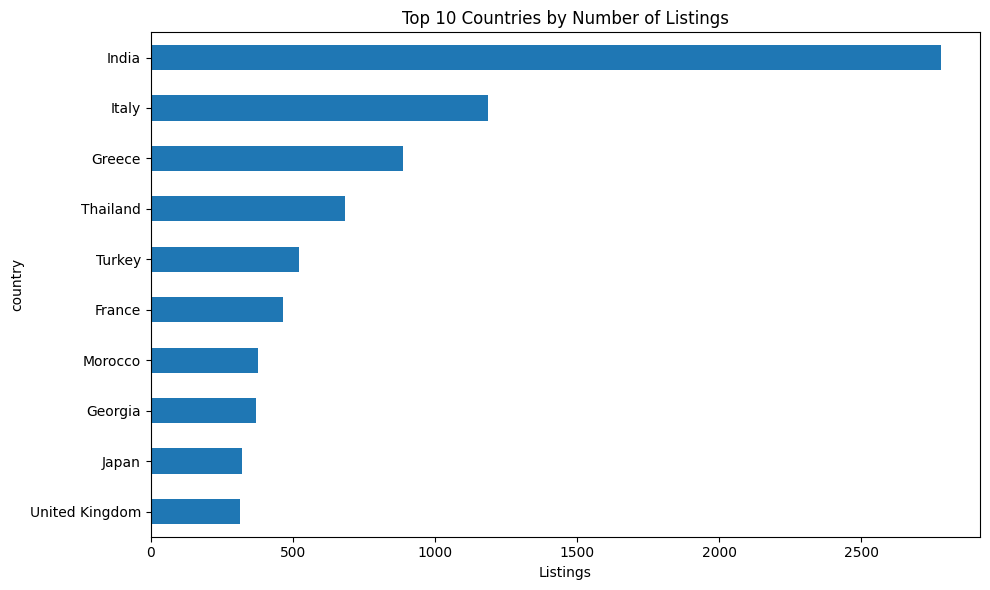

,listings
country,
India,2779
Italy,1187
Greece,889
Thailand,683
Turkey,522
France,466
Morocco,377
Georgia,371
Japan,322


In [5]:
country_counts = data["country"].value_counts().head(10).sort_values()
plt.figure()
country_counts.plot(kind="barh")
plt.title("Top 10 Countries by Number of Listings")
plt.xlabel("Listings")
plt.tight_layout()
plt.show()
display(country_counts.sort_values(ascending=False).to_frame("listings"))


## 5. Price Analysis

Mean price: 17697.8


Median price: 8175.0


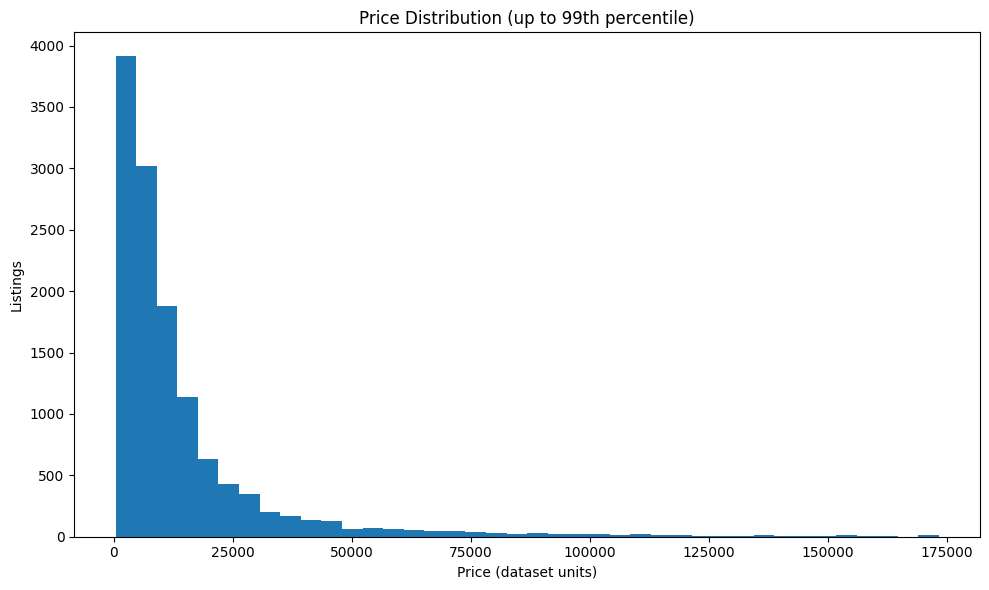

99th percentile: 173970.64
Maximum: 1907963


In [6]:
print("Mean price:", round(data["price"].mean(), 2))
print("Median price:", round(data["price"].median(), 2))
p99 = data["price"].quantile(0.99)
plt.figure()
data.loc[data["price"] <= p99, "price"].plot(kind="hist", bins=40)
plt.title("Price Distribution (up to 99th percentile)")
plt.xlabel("Price (dataset units)")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()
print("99th percentile:", round(p99, 2))
print("Maximum:", data["price"].max())


## 6. Rating Analysis

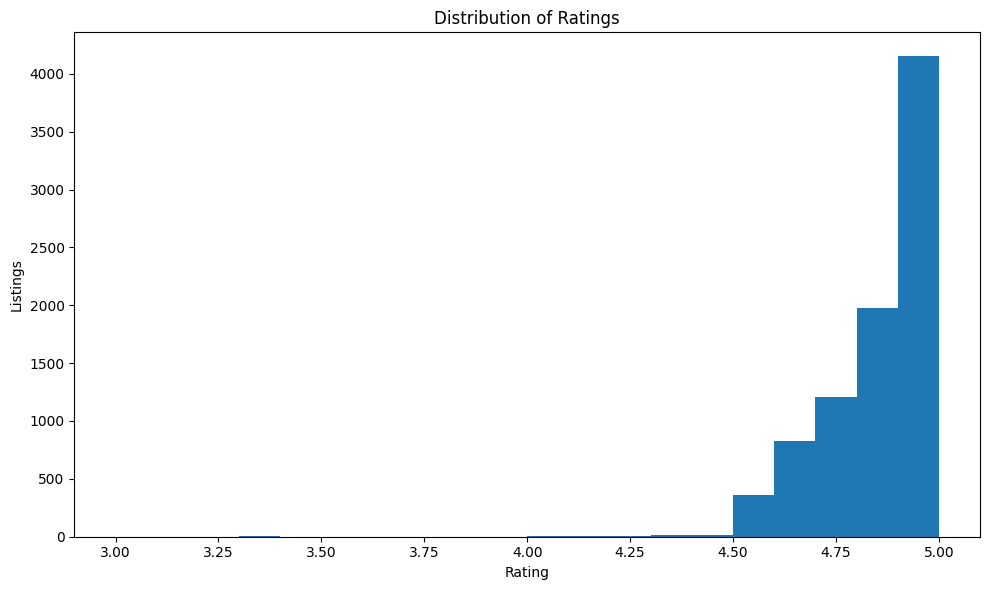

Average rating among rated listings: 4.857


In [7]:
plt.figure()
data["rating_numeric"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()
print("Average rating among rated listings:", round(data["rating_numeric"].mean(), 3))


## 7. Capacity and Property Features

,count,mean,median
guests,,,
1,127,4266.110236,2307.0
2,3729,8194.521856,5454.0
3,1228,7543.410423,4873.5
4,2607,10868.574223,7894.0
5,702,12867.351852,9463.5
6,1471,19420.792658,11740.0
7,253,16211.972332,13628.0
8,732,29236.005464,16937.5
9,201,23749.771144,14200.0


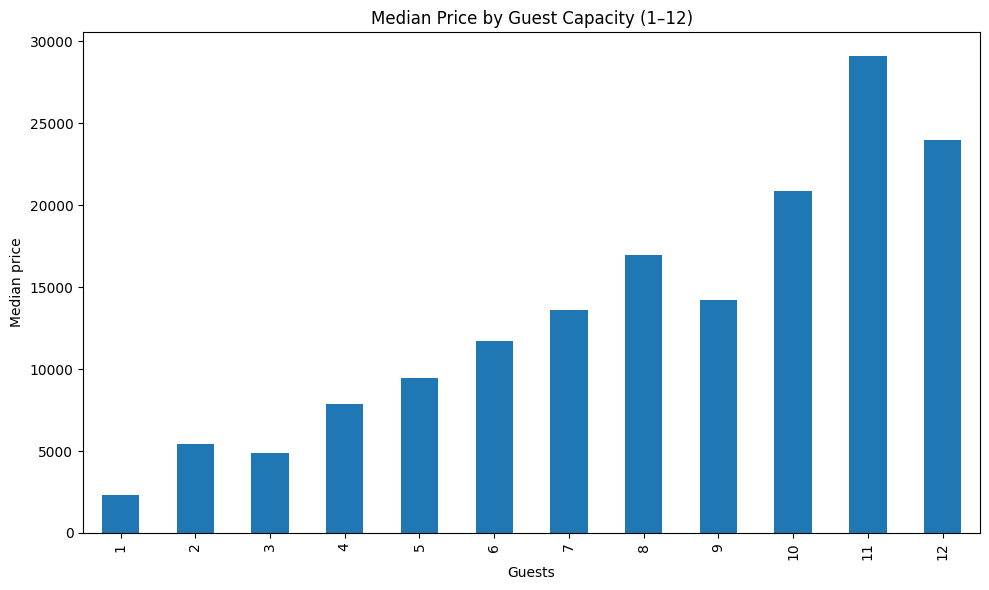

,price,beds,guests,bedrooms,bathrooms,reviews_numeric,rating_numeric
price,1.00,0.23,0.32,0.34,0.36,-0.07,0.08
beds,0.23,1.00,0.67,0.77,0.60,-0.08,-0.01
guests,0.32,0.67,1.00,0.71,0.67,-0.09,-0.03
bedrooms,0.34,0.77,0.71,1.00,0.82,-0.10,-0.00
bathrooms,0.36,0.60,0.67,0.82,1.00,-0.11,-0.01
reviews_numeric,-0.07,-0.08,-0.09,-0.10,-0.11,1.00,-0.02
rating_numeric,0.08,-0.01,-0.03,-0.00,-0.01,-0.02,1.00


In [8]:
capacity = data.groupby("guests")["price"].agg(["count","mean","median"]).sort_index()
display(capacity.head(15))
plt.figure()
capacity.loc[capacity.index <= 12, "median"].plot(kind="bar")
plt.title("Median Price by Guest Capacity (1–12)")
plt.xlabel("Guests")
plt.ylabel("Median price")
plt.tight_layout()
plt.show()
display(data[["price","beds","guests","bedrooms","bathrooms","reviews_numeric","rating_numeric"]].corr(numeric_only=True).round(2))


## 8. Country-Level Price Comparison

,listings,median_price,avg_rating
country,,,
Maldives,41,45516.0,4.755714
United Arab Emirates,52,36742.5,4.835600
Canada,37,23731.0,4.925806
United States,191,20651.0,4.915341
Australia,25,20233.0,4.912000
Israel,137,20091.0,4.870921
Iceland,34,18405.5,4.895938
Greece,889,16480.0,4.871356
Norway,211,14115.0,4.882688


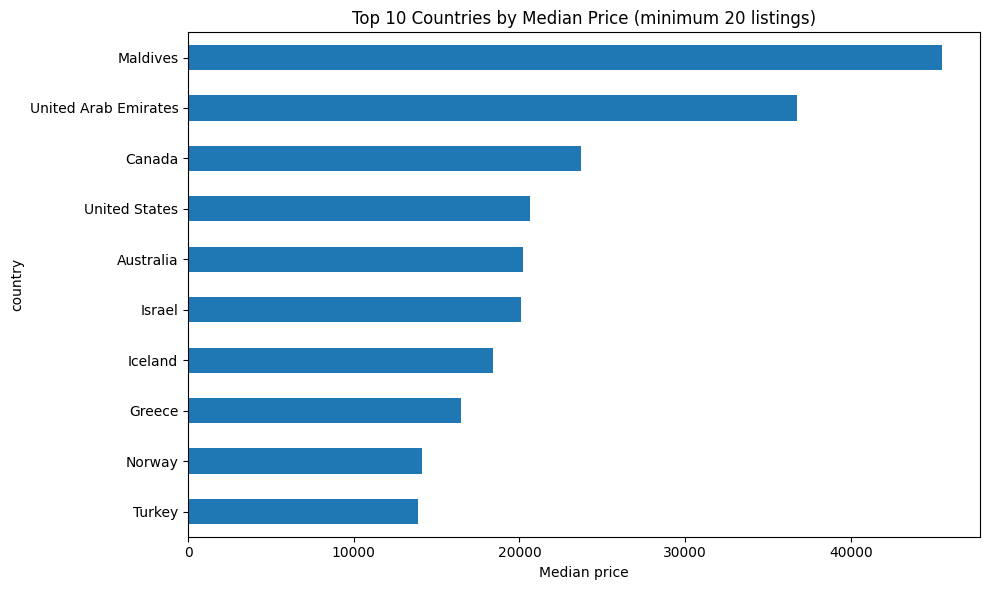

In [9]:
country_summary = (
    data.groupby("country")
    .agg(listings=("id","count"), median_price=("price","median"), avg_rating=("rating_numeric","mean"))
    .query("listings >= 20")
    .sort_values("median_price", ascending=False)
)
display(country_summary.head(15))
plt.figure()
country_summary.head(10)["median_price"].sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Median Price (minimum 20 listings)")
plt.xlabel("Median price")
plt.tight_layout()
plt.show()


## 9. Key Findings
1. The dataset contains 12,805 listings across many countries.
2. Price is strongly right-skewed, so median price is often more representative than the mean.
3. Many listings are marked `New`; rating analysis therefore uses only numeric ratings.
4. Listing volume is concentrated in a smaller group of countries.
5. Guest capacity, beds, bedrooms, and bathrooms are useful dimensions for price comparison.
6. Because currency is not supplied, price comparisons are relative to the dataset rather than claims about USD or another currency.


## 10. Conclusion and Future Work
The analysis turns raw Airbnb listings into a useful view of market size, pricing, ratings, and property capacity.

**Limitations:** no currency field, no live data, inconsistent address structure, and possible price outliers.

**Future work:** add a price prediction model, geospatial mapping, city extraction, historical trend analysis, and online deployment.
